# 🇻 Vietnamese Financial News Summarization — Fine-tuning Pipeline

**Đề tài**: Tóm tắt văn bản tiếng Việt chuyên biệt (VnExpress)

**Mục tiêu**:
- Fine-tune ≥ 2 mô hình pretrained tiếng Việt
- Ràng buộc độ dài output: 20–25% so với văn bản gốc
- Bảo toàn 100% số liệu, con số trong bản tóm tắt
- Đánh giá: ROUGE, BLEU, METEOR, BERTScore, Number Accuracy, Length Compliance

**Mô hình**:
1. `VietAI/vit5-base` — Two-stage fine-tuning
2. `vinai/bartpho-word` — Fine-tuning trực tiếp

**Strategy**: Two-stage training (multi-domain XL-Sum → domain-specific VnExpress)

---

##  CELL 1 — Cài đặt thư viện

In [1]:
# ============================================================
# CELL 1 — CÀI ĐẶT THƯ VIỆN
# ============================================================

!pip uninstall -y transformers peft accelerate sentence-transformers

!pip install -q \
transformers==4.41.2 \
accelerate==0.30.1 \
peft==0.11.1 \
sentence-transformers==3.0.1 \
datasets \
evaluate \
sacrebleu \
rouge_score \
bert_score \
sentencepiece \
gradio \
nltk \
plotly \
pandas \
py7zr \
bitsandbytes \
huggingface_hub

import nltk

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)

print(' Cài đặt hoàn tất!')

Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2
Found existing installation: peft 0.11.1
Uninstalling peft-0.11.1:
  Successfully uninstalled peft-0.11.1
Found existing installation: accelerate 0.30.1
Uninstalling accelerate-0.30.1:
  Successfully uninstalled accelerate-0.30.1
Found existing installation: sentence-transformers 3.0.1
Uninstalling sentence-transformers-3.0.1:
  Successfully uninstalled sentence-transformers-3.0.1
 Cài đặt hoàn tất!


## 🔗 CELL 2 — Mount Google Drive & Import

In [2]:
# ============================================================
# CELL 2 — MOUNT GOOGLE DRIVE & IMPORT THƯ VIỆN
# ============================================================
import subprocess
subprocess.run(['umount', '/content/drive'], capture_output=True)
subprocess.run(['rm', '-rf', '/content/drive'], capture_output=True)

from google.colab import drive
drive.mount('/content/drive')

import os, re, json, math, random, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from collections import defaultdict
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# Transformers
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback,
    GenerationConfig
)
from datasets import Dataset, DatasetDict, load_dataset
from peft import LoraConfig, get_peft_model, TaskType
import evaluate

# ---- Paths ----
DATA_DIR   = '/content/drive/MyDrive/nlp'
OUTPUT_DIR = '/content/drive/MyDrive/nlp/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'  Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(' Import hoàn tất!')

Mounted at /content/drive
  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
 Import hoàn tất!


## 📊 CELL 3 — Load & Khám phá Dữ liệu

 Train: 494 mẫu
 Val  : 62 mẫu
 Test : 62 mẫu

[Train]
  content  — Mean: 837 | Min: 78 | Max: 3405
  Summary  — Mean: 213 | Min: 21 | Max: 600
  Ratio(%) — Mean: 26.2% | 20-25% coverage: 10.3%

[Val]
  content  — Mean: 790 | Min: 294 | Max: 1934
  Summary  — Mean: 207 | Min: 95 | Max: 491
  Ratio(%) — Mean: 26.9% | 20-25% coverage: 9.7%

[Test]
  content  — Mean: 823 | Min: 131 | Max: 1855
  Summary  — Mean: 215 | Min: 39 | Max: 438
  Ratio(%) — Mean: 26.4% | 20-25% coverage: 9.7%


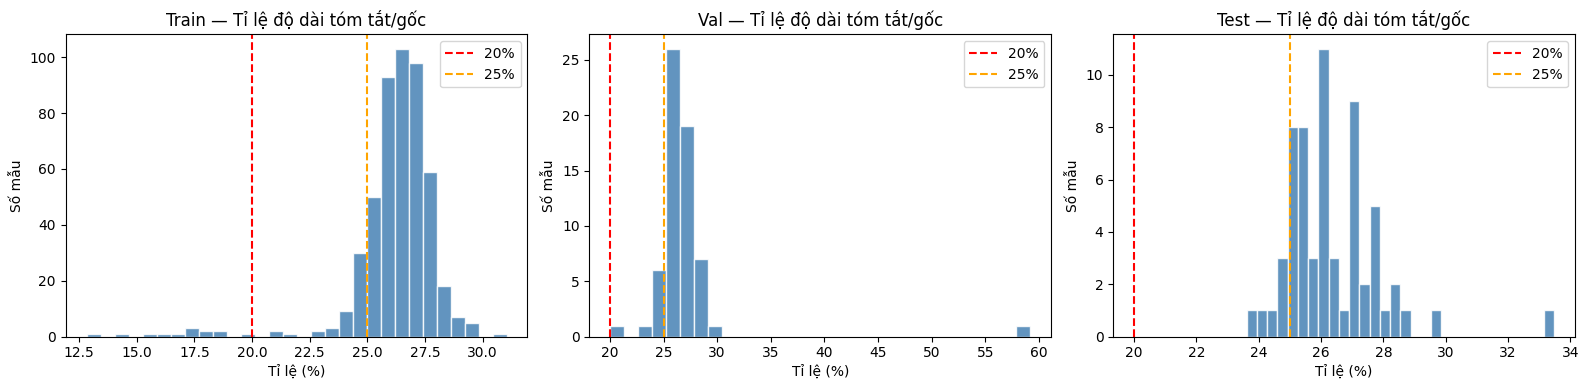

 Khám phá dữ liệu hoàn tất!


In [3]:
# ============================================================
# CELL 3 — LOAD & KHÁM PHÁ DỮ LIỆU
# ============================================================
train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')

# Đổi tên cột nếu cần (đảm bảo 2 cột: content, summary)
for df in [train_df, val_df, test_df]:
    df.columns = [c.strip().lower() for c in df.columns]
    if 'article' in df.columns and 'content' not in df.columns:
        df.rename(columns={'article': 'content'}, inplace=True)

print('='*60)
print(f' Train: {len(train_df)} mẫu')
print(f' Val  : {len(val_df)} mẫu')
print(f' Test : {len(test_df)} mẫu')
print('='*60)

# ---- Thống kê độ dài ----
def count_words(text):
    return len(str(text).split())

for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    src_len  = df['content'].apply(count_words)
    summ_len = df['summary'].apply(count_words)
    ratio    = summ_len / src_len * 100
    print(f'\n[{name}]')
    print(f'  content  — Mean: {src_len.mean():.0f} | Min: {src_len.min()} | Max: {src_len.max()}')
    print(f'  Summary  — Mean: {summ_len.mean():.0f} | Min: {summ_len.min()} | Max: {summ_len.max()}')
    print(f'  Ratio(%) — Mean: {ratio.mean():.1f}% | 20-25% coverage: {((ratio>=20)&(ratio<=25)).mean()*100:.1f}%')

# ---- Visualize phân phối ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    src_len  = df['content'].apply(count_words)
    summ_len = df['summary'].apply(count_words)
    ratio    = summ_len / src_len * 100
    ax.hist(ratio, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(20, color='red', ls='--', lw=1.5, label='20%')
    ax.axvline(25, color='orange', ls='--', lw=1.5, label='25%')
    ax.set_title(f'{name} — Tỉ lệ độ dài tóm tắt/gốc')
    ax.set_xlabel('Tỉ lệ (%)')
    ax.set_ylabel('Số mẫu')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/data_length_distribution.png', dpi=150)
plt.show()
print(' Khám phá dữ liệu hoàn tất!')

##  CELL 4 — Tiện ích Số liệu & Tăng cường Dữ liệu

In [4]:
# ============================================================
# CELL 4 — TIỆN ÍCH SỐ LIỆU & TĂNG CƯỜNG DỮ LIỆU
# ============================================================

# ---- Regex trích xuất số ----
NUMBER_PATTERN = re.compile(
    r'\b(\d{1,3}(?:[.,]\d{3})*(?:[.,]\d+)?|\d+(?:[.,]\d+)?'  # số thông thường
    r'|\d+(?:/\d+)+'  # phân số / tỉ số
    r'|\d+(?:-\d+)+'  # dải số
    r')\b'
)

def extract_numbers(text: str) -> set:
    """Trích xuất tất cả chuỗi số từ văn bản, chuẩn hóa về string."""
    nums = NUMBER_PATTERN.findall(str(text))
    normalized = set()
    for n in nums:
        # Chuẩn hóa: bỏ dấu phân cách nghìn
        n_clean = n.replace(',', '').replace('.', '')
        normalized.add(n)
        normalized.add(n_clean)
    return normalized

def number_accuracy(source: str, summary: str) -> float:
    """Tỉ lệ số trong summary khớp với source."""
    src_nums  = extract_numbers(source)
    summ_nums = extract_numbers(summary)
    if not summ_nums:
        return 1.0  # Không có số thì không tính lỗi
    # Mỗi số trong summary phải có trong source
    matched = sum(1 for n in summ_nums if n in src_nums)
    return matched / len(summ_nums)

def length_compliance(source: str, summary: str, lo=0.20, hi=0.25) -> bool:
    """Kiểm tra summary có trong khoảng 20-25% độ dài source không."""
    src_words  = count_words(source)
    summ_words = count_words(summary)
    ratio = summ_words / max(src_words, 1)
    return lo <= ratio <= hi

# ---- Tăng cường dữ liệu (Data Augmentation) ----
def augment_dataframe(df: pd.DataFrame, factor: int = 1) -> pd.DataFrame:
    """
    Tăng cường dữ liệu nhẹ:
    - Shuffle câu trong content (giữ nguyên summary)
    - Chỉ áp dụng cho train, không làm mất số liệu
    """
    augmented = []
    for _, row in df.iterrows():
        augmented.append(row)
        for _ in range(factor - 1):
            sentences = re.split(r'(?<=[.!?])\s+', str(row['content']))
            if len(sentences) > 3:
                # Shuffle chỉ phần giữa, giữ nguyên đầu/cuối
                middle = sentences[1:-1]
                random.shuffle(middle)
                new_ctx = ' '.join([sentences[0]] + middle + [sentences[-1]])
            else:
                new_ctx = row['content']
            new_row = row.copy()
            new_row['content'] = new_ctx
            augmented.append(new_row)
    return pd.DataFrame(augmented).reset_index(drop=True)

# Tăng gấp 2 lần train (augmentation factor=2)
train_aug_df = augment_dataframe(train_df, factor=2)
print(f' Train sau augmentation: {len(train_aug_df)} mẫu (gốc: {len(train_df)})')

# Kiểm tra Number Accuracy trên tập train
na_scores = [
    number_accuracy(row['content'], row['summary'])
    for _, row in train_df.iterrows()
]
lc_scores = [
    length_compliance(row['content'], row['summary'])
    for _, row in train_df.iterrows()
]
print(f' Number Accuracy (train, baseline): {np.mean(na_scores)*100:.1f}%')
print(f' Length Compliance 20-25% (train) : {np.mean(lc_scores)*100:.1f}%')
print(' Tiện ích số liệu sẵn sàng!')

 Train sau augmentation: 988 mẫu (gốc: 494)
 Number Accuracy (train, baseline): 98.9%
 Length Compliance 20-25% (train) : 10.3%
 Tiện ích số liệu sẵn sàng!


## 🏗️ CELL 5 — Two-Stage Data: XL-Sum (Stage 1)

In [5]:
!pip uninstall -y datasets
!pip install -q datasets==2.19.1

# # restart runtime
# import os
# os.kill(os.getpid(), 9)

Found existing installation: datasets 2.19.1
Uninstalling datasets-2.19.1:
  Successfully uninstalled datasets-2.19.1


In [6]:
# ============================================================
# CELL 5 — TWO-STAGE DATA: LOAD XL-SUM TIẾNG VIỆT (STAGE 1)
# ============================================================
# Strategy: Fine-tune trên XL-Sum Vietnamese trước để học cách tóm tắt
# Sau đó fine-tune tiếp trên dữ liệu VnExpress của nhóm (Stage 2)
# --> Giúp mô hình generalize tốt hơn, đặc biệt với dữ liệu nhỏ

print('  Đang tải XL-Sum (Vietnamese)...')
xlsum = load_dataset('GEM/xlsum', 'vietnamese', trust_remote_code=True)

# Chỉ lấy một phần nhỏ để stage 1 không quá lâu
N_XLSUM_TRAIN = 3000
N_XLSUM_VAL   = 300

xlsum_train = xlsum['train'].shuffle(seed=SEED).select(range(N_XLSUM_TRAIN))
xlsum_val   = xlsum['validation'].shuffle(seed=SEED).select(range(N_XLSUM_VAL))

# Chuyển về DataFrame đồng nhất format
def xlsum_to_df(hf_dataset):
    return pd.DataFrame({
        'content': hf_dataset['text'],
        'summary': hf_dataset['target']
    })

xlsum_train_df = xlsum_to_df(xlsum_train)
xlsum_val_df   = xlsum_to_df(xlsum_val)

print(f' XL-Sum Train: {len(xlsum_train_df)} | Val: {len(xlsum_val_df)}')
print(f'   Ví dụ content (100 ký tự đầu): {xlsum_train_df["content"].iloc[0][:100]}')

  Đang tải XL-Sum (Vietnamese)...
 XL-Sum Train: 3000 | Val: 300
   Ví dụ content (100 ký tự đầu): Trang web sứ quán Việt Nam ở Chile

Thông cáo được truyền thông Việt Nam hôm 23/1 dẫn lại nói: "Văn 


##  CELL 6 — Cấu hình Hyperparameters & Tokenization

In [7]:
# ============================================================
# CELL 6 — CẤU HÌNH HYPERPARAMETERS & HÀM TOKENIZATION
# ============================================================

# ============= CẤU HÌNH CHUNG =============
MAX_INPUT_LEN  = 1024   # Token tối đa cho input
MAX_TARGET_LEN = 256    # Token tối đa cho output
MIN_TARGET_LEN = 50     # Minimum tokens sinh ra

# Generation config — dùng chung
GEN_CONFIG = dict(
    num_beams          = 4,
    length_penalty     = 1.2,   # > 1 khuyến khích output dài hơn
    no_repeat_ngram_size = 3,
    early_stopping     = True,
    min_length         = MIN_TARGET_LEN,
    max_length         = MAX_TARGET_LEN,
)

# ============= MODEL CONFIGS =============
MODEL_CONFIGS = {
    'vit5': {
        'model_name' : 'VietAI/vit5-base',
        'prefix'     : 'summarize: ',
        'batch_size' : 2,
        'grad_accum' : 8,
        'lr_stage1'  : 3e-4,
        'lr_stage2'  : 1e-4,
        'epochs_s1'  : 3,
        'epochs_s2'  : 5,
        'use_lora'   : False,  # ViT5-base nhẹ, full fine-tune
    },
    'bartpho': {
        'model_name' : 'vinai/bartpho-word',
        'prefix'     : '',     # BARTpho không cần prefix
        'batch_size' : 2,
        'grad_accum' : 8,
        'lr_stage1'  : 2e-4,
        'lr_stage2'  : 5e-5,
        'epochs_s1'  : 3,
        'epochs_s2'  : 5,
        'use_lora'   : True,   # BARTpho lớn hơn, dùng LoRA
        'lora_r'     : 16,
        'lora_alpha' : 32,
        'lora_dropout': 0.1,
    },
}

# ============= HÀM TOKENIZATION =============
def make_tokenize_fn(tokenizer, prefix='', max_input=MAX_INPUT_LEN, max_target=MAX_TARGET_LEN):
    """Tạo hàm tokenize phù hợp với từng tokenizer."""
    def tokenize(examples):
        inputs = [prefix + str(t) for t in examples['content']]
        targets = [str(t) for t in examples['summary']]

        model_inputs = tokenizer(
            inputs,
            max_length=max_input,
            truncation=True,
            padding=False,
        )
        with tokenizer.as_target_tokenizer():
            labels = tokenizer(
                targets,
                max_length=max_target,
                truncation=True,
                padding=False,
            )
        model_inputs['labels'] = labels['input_ids']
        return model_inputs
    return tokenize

def df_to_hf_dataset(df):
    """Chuyển DataFrame → HuggingFace Dataset."""
    return Dataset.from_pandas(df[['content', 'summary']].dropna().reset_index(drop=True))

# ============= HÀM TÍNH LENGTH-AWARE TARGET =============
def compute_target_length(source_text: str, tokenizer) -> tuple:
    """Tính min/max token target dựa trên độ dài nguồn (ràng buộc 20-25%)."""
    src_tokens = len(tokenizer.encode(source_text))
    min_t = max(30,  int(src_tokens * 0.20))
    max_t = min(512, int(src_tokens * 0.25))
    return min_t, max_t

print(' Cấu hình hyperparameters hoàn tất!')
print('\nTóm tắt cấu hình:')
for mname, cfg in MODEL_CONFIGS.items():
    print(f'  [{mname}] {cfg["model_name"]} | LoRA={cfg["use_lora"]} | BS={cfg["batch_size"]}x{cfg["grad_accum"]} | LR_s2={cfg["lr_stage2"]}')

 Cấu hình hyperparameters hoàn tất!

Tóm tắt cấu hình:
  [vit5] VietAI/vit5-base | LoRA=False | BS=2x8 | LR_s2=0.0001
  [bartpho] vinai/bartpho-word | LoRA=True | BS=2x8 | LR_s2=5e-05


##  CELL 7 — Metrics Evaluation Suite

In [8]:
# ============================================================
# CELL 7 — METRICS EVALUATION SUITE
# ============================================================
rouge_metric   = evaluate.load('rouge')
bleu_metric    = evaluate.load('sacrebleu')
meteor_metric  = evaluate.load('meteor')
bertscore_metric = evaluate.load('bertscore')

def compute_all_metrics(predictions: list, references: list, sources: list) -> dict:
    """
    Tính toàn bộ metrics:
    - ROUGE-1/2/L
    - BLEU
    - METEOR
    - BERTScore (F1)
    - Number Accuracy
    - Length Compliance (20-25%)
    """
    results = {}

    # ROUGE
    rouge_out = rouge_metric.compute(
        predictions=predictions,
        references=references,
        use_stemmer=False
    )
    results['rouge1'] = round(rouge_out['rouge1'] * 100, 2)
    results['rouge2'] = round(rouge_out['rouge2'] * 100, 2)
    results['rougeL'] = round(rouge_out['rougeL'] * 100, 2)

    # BLEU
    bleu_out = bleu_metric.compute(
        predictions=predictions,
        references=[[r] for r in references]
    )
    results['bleu'] = round(bleu_out['score'], 2)

    # METEOR
    meteor_out = meteor_metric.compute(
        predictions=predictions,
        references=references
    )
    results['meteor'] = round(meteor_out['meteor'] * 100, 2)

    # BERTScore (dùng multilingual model)
    bs_out = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang='vi',
        model_type='bert-base-multilingual-cased'
    )
    results['bertscore_f1'] = round(np.mean(bs_out['f1']) * 100, 2)

    # Number Accuracy
    na_list = [number_accuracy(src, pred) for src, pred in zip(sources, predictions)]
    results['number_accuracy'] = round(np.mean(na_list) * 100, 2)

    # Length Compliance
    lc_list = [length_compliance(src, pred) for src, pred in zip(sources, predictions)]
    results['length_compliance'] = round(np.mean(lc_list) * 100, 2)

    # Ratio trung bình
    ratios = [
        count_words(pred) / max(count_words(src), 1) * 100
        for src, pred in zip(sources, predictions)
    ]
    results['avg_ratio_pct'] = round(np.mean(ratios), 2)

    return results


def build_compute_metrics_fn(tokenizer, sources_list):
    """Tạo compute_metrics callback cho Trainer (dùng trong eval)."""
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        if isinstance(preds, tuple):
            preds = preds[0]
        # Decode
        preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        decoded_preds  = tokenizer.batch_decode(preds, skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
        decoded_preds  = [p.strip() for p in decoded_preds]
        decoded_labels = [l.strip() for l in decoded_labels]
        # Chỉ tính ROUGE + number_accuracy trong lúc train (nhanh)
        rouge_out = rouge_metric.compute(
            predictions=decoded_preds, references=decoded_labels
        )
        na_list = [number_accuracy(s, p) for s, p in zip(sources_list[:len(decoded_preds)], decoded_preds)]
        return {
            'rouge1': round(rouge_out['rouge1'] * 100, 2),
            'rouge2': round(rouge_out['rouge2'] * 100, 2),
            'rougeL': round(rouge_out['rougeL'] * 100, 2),
            'number_accuracy': round(np.mean(na_list) * 100, 2),
        }
    return compute_metrics

print(' Metrics suite sẵn sàng!')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


 Metrics suite sẵn sàng!


##  CELL 8 — Hàm Fine-tuning Chung (Two-Stage)

In [9]:
# ============================================================
# CELL 8 — HÀM FINE-TUNING CHUNG (TWO-STAGE)
# ============================================================

training_logs = {}  # Lưu loss curves cho tất cả models

class LossLoggerCallback:
    """Thu thập train/eval loss theo epoch."""
    def __init__(self, tag):
        self.tag = tag
        self.logs = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            entry = {'step': state.global_step}
            if 'loss' in logs:      entry['train_loss'] = logs['loss']
            if 'eval_loss' in logs: entry['eval_loss']  = logs['eval_loss']
            if 'eval_rouge1' in logs: entry['eval_rouge1'] = logs['eval_rouge1']
            self.logs.append(entry)

from transformers import TrainerCallback
class LossLoggerCallback(TrainerCallback):
    def __init__(self, tag):
        self.tag = tag
        self.logs = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            entry = {'step': state.global_step}
            if 'loss' in logs:      entry['train_loss'] = round(logs['loss'], 4)
            if 'eval_loss' in logs: entry['eval_loss']  = round(logs['eval_loss'], 4)
            if 'eval_rouge1' in logs: entry['eval_rouge1'] = round(logs['eval_rouge1'], 2)
            self.logs.append(entry)


def run_training_stage(
    model, tokenizer, cfg,
    train_df, val_df,
    output_subdir: str,
    stage_name: str,
    lr: float,
    num_epochs: int,
    log_tag: str,
    resume_from_checkpoint=None,
):
    """Chạy một giai đoạn fine-tuning."""
    tokenize_fn = make_tokenize_fn(tokenizer, prefix=cfg['prefix'])

    hf_train = df_to_hf_dataset(train_df).map(tokenize_fn, batched=True, remove_columns=['content','summary'])
    hf_val   = df_to_hf_dataset(val_df).map(tokenize_fn, batched=True, remove_columns=['content','summary'])

    data_collator = DataCollatorForSeq2Seq(
        tokenizer, model=model, label_pad_token_id=-100, pad_to_multiple_of=8
    )

    val_sources = val_df['content'].tolist()
    compute_metrics = build_compute_metrics_fn(tokenizer, val_sources)

    logger_cb = LossLoggerCallback(tag=log_tag)

    training_args = Seq2SeqTrainingArguments(
        output_dir              = output_subdir,
        num_train_epochs        = num_epochs,
        per_device_train_batch_size = cfg['batch_size'],
        per_device_eval_batch_size  = cfg['batch_size'],
        gradient_accumulation_steps = cfg['grad_accum'],
        learning_rate           = lr,
        weight_decay            = 0.01,
        warmup_ratio            = 0.1,
        lr_scheduler_type       = 'cosine',
        evaluation_strategy     = 'epoch',
        save_strategy           = 'epoch',
        load_best_model_at_end  = True,
        metric_for_best_model   = 'rouge1',
        greater_is_better       = True,
        predict_with_generate   = True,
        generation_max_length   = MAX_TARGET_LEN,
        generation_num_beams    = GEN_CONFIG['num_beams'],
        fp16                    = (DEVICE == 'cuda'),
        logging_steps           = 10,
        report_to               = 'none',
        save_total_limit        = 2,
        seed                    = SEED,
        dataloader_num_workers  = 2,
    )

    trainer = Seq2SeqTrainer(
        model           = model,
        args            = training_args,
        train_dataset   = hf_train,
        eval_dataset    = hf_val,
        tokenizer       = tokenizer,
        data_collator   = data_collator,
        compute_metrics = compute_metrics,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2), logger_cb],
    )

    print(f'\n [{stage_name}] Bắt đầu huấn luyện...')
    trainer.train(resume_from_checkpoint=resume_from_checkpoint)
    training_logs[log_tag] = logger_cb.logs
    print(f' [{stage_name}] Hoàn tất!')
    return trainer


def apply_lora(model, cfg):
    """Áp dụng LoRA vào model nếu cần."""
    lora_cfg = LoraConfig(
        task_type    = TaskType.SEQ_2_SEQ_LM,
        r            = cfg.get('lora_r', 16),
        lora_alpha   = cfg.get('lora_alpha', 32),
        lora_dropout = cfg.get('lora_dropout', 0.1),
        target_modules = ['q_proj', 'v_proj'],  # BARTpho attention
        bias         = 'none',
    )
    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()
    return model

print(' Hàm fine-tuning sẵn sàng!')

 Hàm fine-tuning sẵn sàng!


##  CELL 9 — Fine-tune Model 1: ViT5 (Two-Stage)

In [10]:
def load_latest_checkpoint(path, fallback_model=None):
    """
    Load checkpoint mới nhất từ thư mục nếu có.
    Trả về (model, ckpt_path) để resume training.
    - ckpt_path != None → resume từ checkpoint đó
    - ckpt_path == None → train từ đầu
    """
    if os.path.exists(path):
        checkpoints = [
            d for d in os.listdir(path)
            if d.startswith('checkpoint-') and os.path.isdir(os.path.join(path, d))
        ]
        if checkpoints:
            latest = sorted(checkpoints, key=lambda x: int(x.split('-')[-1]))[-1]
            ckpt_path = os.path.join(path, latest)
            print(f" Tìm thấy checkpoint: {ckpt_path} → sẽ resume")
            return AutoModelForSeq2SeqLM.from_pretrained(ckpt_path), ckpt_path

        # Không có sub-checkpoint, thử load trực tiếp thư mục (model đã save)
        try:
            print(f" Loading saved model từ: {path}")
            return AutoModelForSeq2SeqLM.from_pretrained(path), None
        except Exception:
            pass

    # Fallback
    if fallback_model is None:
        raise ValueError(f"Không có checkpoint tại '{path}' và không có fallback!")

    if isinstance(fallback_model, str):
        print(f"  Không có checkpoint → load base model: {fallback_model}")
        return AutoModelForSeq2SeqLM.from_pretrained(fallback_model), None
    else:
        print(f"  Không có checkpoint → dùng model từ stage trước")
        return fallback_model, None


In [22]:
# ============================================================
# CELL 9 — FINE-TUNE MODEL 1: ViT5-base (TWO-STAGE)
# ============================================================
# Stage 1: XL-Sum Vietnamese (học cách tóm tắt tổng quát)
# Stage 2: VnExpress dataset (domain-specific fine-tuning)
# ============================================================

cfg_vit5 = MODEL_CONFIGS['vit5']
VIT5_DIR_S1    = f'{OUTPUT_DIR}/vit5_stage1'   # trỏ thư mục cha, không hardcode checkpoint
VIT5_DIR_S2    = f'{OUTPUT_DIR}/vit5_stage2'
VIT5_DIR_FINAL = f'{OUTPUT_DIR}/vit5_final'
os.makedirs(VIT5_DIR_S1, exist_ok=True)
os.makedirs(VIT5_DIR_S2, exist_ok=True)

print(f' Loading tokenizer: {cfg_vit5["model_name"]}...')
vit5_tokenizer = AutoTokenizer.from_pretrained(cfg_vit5['model_name'])

n_params = sum(p.numel() for p in AutoModelForSeq2SeqLM.from_pretrained(cfg_vit5['model_name']).parameters())
print(f'   Tham số: {n_params/1e6:.1f}M | Full fine-tune (không LoRA)')

# ---------- STAGE 1: XL-Sum ----------
# Có checkpoint → resume; chưa có → load base model
vit5_model, ckpt_s1 = load_latest_checkpoint(
    VIT5_DIR_S1,
    fallback_model=cfg_vit5['model_name'],
)

trainer_vit5_s1 = run_training_stage(
    model                  = vit5_model,
    tokenizer              = vit5_tokenizer,
    cfg                    = cfg_vit5,
    train_df               = xlsum_train_df,
    val_df                 = xlsum_val_df,
    output_subdir          = VIT5_DIR_S1,
    stage_name             = 'ViT5 | Stage 1 | XL-Sum',
    lr                     = cfg_vit5['lr_stage1'],
    num_epochs             = cfg_vit5['epochs_s1'],
    log_tag                = 'vit5_stage1',
    resume_from_checkpoint = ckpt_s1,
)

# Lấy best model từ stage 1
vit5_model = trainer_vit5_s1.model

# ---------- STAGE 2: VnExpress ----------
# Có checkpoint S2 → resume; chưa có → dùng best model từ S1
vit5_model, ckpt_s2 = load_latest_checkpoint(
    VIT5_DIR_S2,
    fallback_model=vit5_model,
)

trainer_vit5_s2 = run_training_stage(
    model                  = vit5_model,
    tokenizer              = vit5_tokenizer,
    cfg                    = cfg_vit5,
    train_df               = train_aug_df,
    val_df                 = val_df,
    output_subdir          = VIT5_DIR_S2,
    stage_name             = 'ViT5 | Stage 2 | VnExpress',
    lr                     = cfg_vit5['lr_stage2'],
    num_epochs             = cfg_vit5['epochs_s2'],
    log_tag                = 'vit5_stage2',
    resume_from_checkpoint = ckpt_s2,
)

# Lưu model cuối
vit5_model = trainer_vit5_s2.model
vit5_model.save_pretrained(VIT5_DIR_FINAL)
vit5_tokenizer.save_pretrained(VIT5_DIR_FINAL)
print('\n ViT5 model đã được lưu tại:', VIT5_DIR_FINAL)


 Loading tokenizer: VietAI/vit5-base...
   Tham số: 226.0M | Full fine-tune (không LoRA)
 Tìm thấy checkpoint: /content/drive/MyDrive/nlp/outputs/vit5_stage1/checkpoint-561 → sẽ resume


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]


 [ViT5 | Stage 1 | XL-Sum] Bắt đầu huấn luyện...


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].
There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


...

Map:   0%|          | 0/62 [00:00<?, ? examples/s]


 [ViT5 | Stage 2 | VnExpress] Bắt đầu huấn luyện...


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].
There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Epoch,Training Loss,Validation Loss


 [ViT5 | Stage 2 | VnExpress] Hoàn tất!

 ViT5 model đã được lưu tại: /content/drive/MyDrive/nlp/outputs/vit5_final


## CELL 10 — Fine-tune Model 2: BARTpho (LoRA + Two-Stage)

In [14]:
# ============================================================
# CELL 10 — FINE-TUNE MODEL 2: BARTpho-word (LoRA + TWO-STAGE)
# ============================================================

cfg_bart = MODEL_CONFIGS['bartpho']
BART_DIR_S1    = f'{OUTPUT_DIR}/bartpho_stage1'
BART_DIR_S2    = f'{OUTPUT_DIR}/bartpho_stage2'
BART_DIR_FINAL = f'{OUTPUT_DIR}/bartpho_final'
os.makedirs(BART_DIR_S1, exist_ok=True)
os.makedirs(BART_DIR_S2, exist_ok=True)

print(f' Loading tokenizer: {cfg_bart["model_name"]}...')
bart_tokenizer = AutoTokenizer.from_pretrained(cfg_bart['model_name'])

# ---------- STAGE 1: XL-Sum ----------
# Có checkpoint → resume (LoRA đã được lưu trong checkpoint, không apply lại)
# Chưa có → load base model rồi apply LoRA
bart_model, ckpt_bs1 = load_latest_checkpoint(
    BART_DIR_S1,
    fallback_model=cfg_bart['model_name'],
)
if ckpt_bs1 is None:
    # Chỉ apply LoRA khi chưa có checkpoint (lần đầu train)
    bart_model = apply_lora(bart_model, cfg_bart)
    print(" Đã apply LoRA cho BARTpho")
else:
    print(" LoRA đã có trong checkpoint, không apply lại")

trainer_bart_s1 = run_training_stage(
    model                  = bart_model,
    tokenizer              = bart_tokenizer,
    cfg                    = cfg_bart,
    train_df               = xlsum_train_df,
    val_df                 = xlsum_val_df,
    output_subdir          = BART_DIR_S1,
    stage_name             = 'BARTpho | Stage 1 | XL-Sum',
    lr                     = cfg_bart['lr_stage1'],
    num_epochs             = cfg_bart['epochs_s1'],
    log_tag                = 'bartpho_stage1',
    resume_from_checkpoint = ckpt_bs1,
)

# Lấy best model từ stage 1
bart_model = trainer_bart_s1.model

# ---------- STAGE 2: VnExpress ----------
# Có checkpoint S2 → resume; chưa có → dùng best model từ S1
bart_model, ckpt_bs2 = load_latest_checkpoint(
    BART_DIR_S2,
    fallback_model=bart_model,
)

trainer_bart_s2 = run_training_stage(
    model                  = bart_model,
    tokenizer              = bart_tokenizer,
    cfg                    = cfg_bart,
    train_df               = train_aug_df,
    val_df                 = val_df,
    output_subdir          = BART_DIR_S2,
    stage_name             = 'BARTpho | Stage 2 | VnExpress',
    lr                     = cfg_bart['lr_stage2'],
    num_epochs             = cfg_bart['epochs_s2'],
    log_tag                = 'bartpho_stage2',
    resume_from_checkpoint = ckpt_bs2,
)

bart_model = trainer_bart_s2.model
bart_model.save_pretrained(BART_DIR_FINAL)
bart_tokenizer.save_pretrained(BART_DIR_FINAL)
print('\n BARTpho model đã được lưu tại:', BART_DIR_FINAL)


 Loading tokenizer: vinai/bartpho-word...
 Tìm thấy checkpoint: /content/drive/MyDrive/nlp/outputs/bartpho_stage1/checkpoint-561 → sẽ resume
 LoRA đã có trong checkpoint, không apply lại


Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]


 [BARTpho | Stage 1 | XL-Sum] Bắt đầu huấn luyện...


ValueError: Can't find a checkpoint index (pytorch_model.bin.index.json or model.safetensors.index.json) in /content/drive/MyDrive/nlp/outputs/bartpho_stage1/checkpoint-561.

##  CELL 11 — Visualize Train/Val Loss Curves

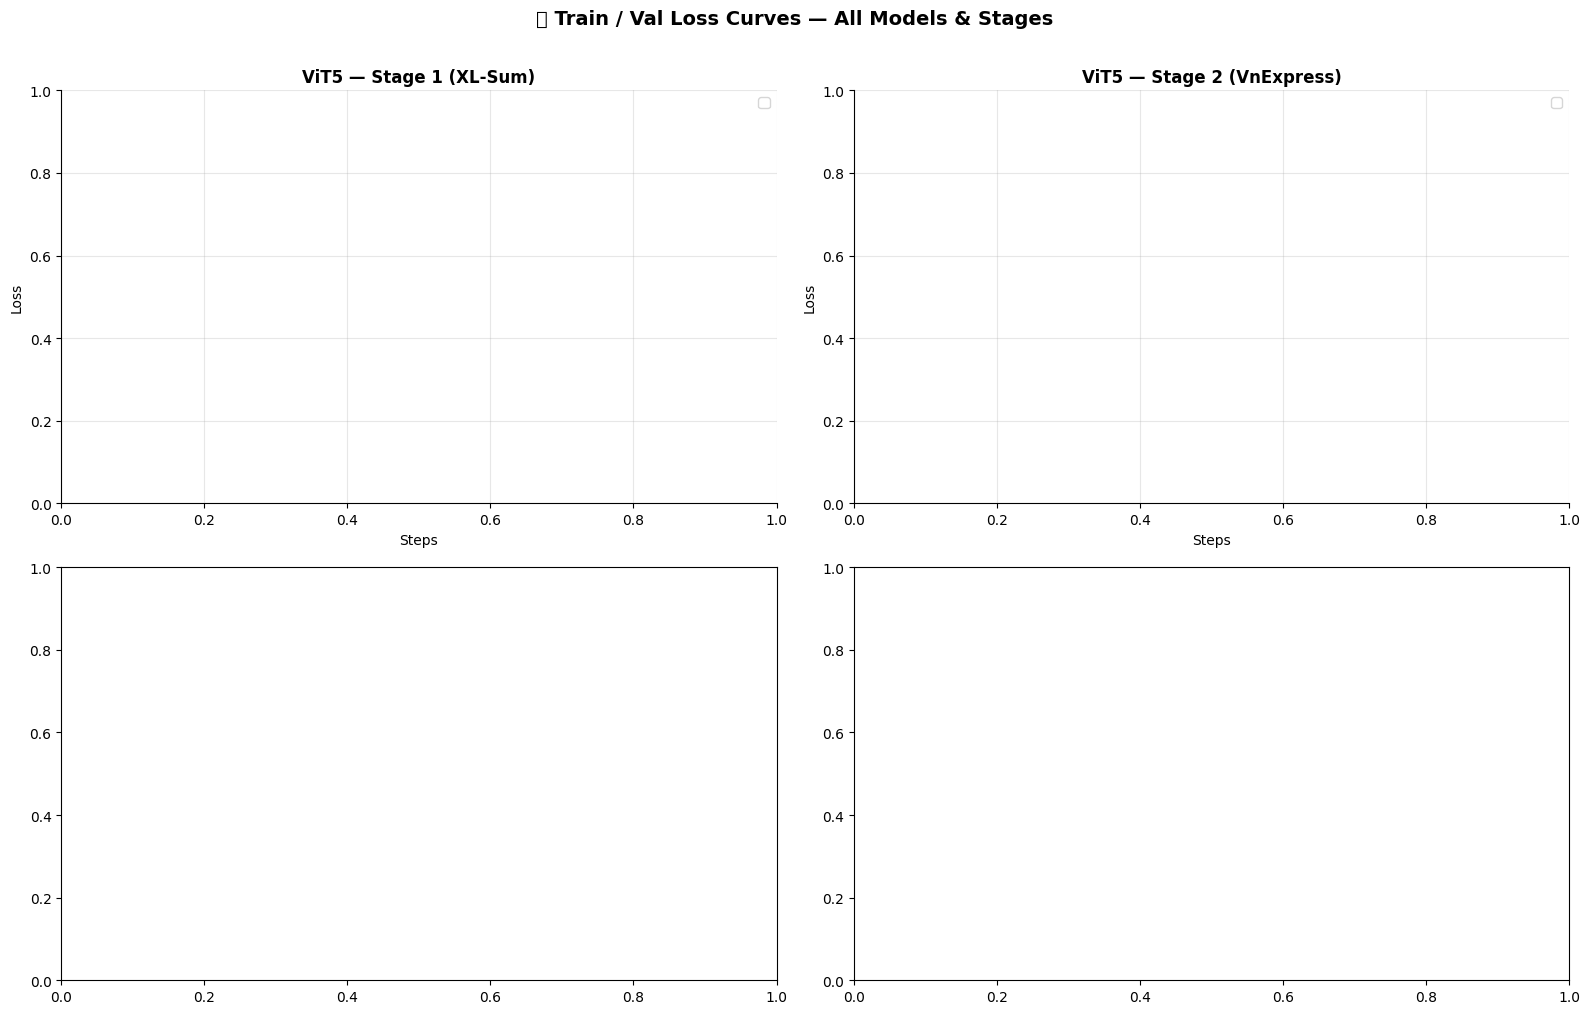

 Loss curves đã được lưu!


In [15]:
# ============================================================
# CELL 11 — VISUALIZE TRAIN/VAL LOSS CURVES
# ============================================================

def plot_loss_curves(training_logs: dict, save_path: str = None):
    """Vẽ loss curves cho tất cả models và stages."""
    COLORS = {
        'vit5_stage1'    : ('#2196F3', '#0D47A1'),
        'vit5_stage2'    : ('#4CAF50', '#1B5E20'),
        'bartpho_stage1' : ('#FF9800', '#E65100'),
        'bartpho_stage2' : ('#E91E63', '#880E4F'),
    }
    LABELS = {
        'vit5_stage1'    : 'ViT5 — Stage 1 (XL-Sum)',
        'vit5_stage2'    : 'ViT5 — Stage 2 (VnExpress)',
        'bartpho_stage1' : 'BARTpho — Stage 1 (XL-Sum)',
        'bartpho_stage2' : 'BARTpho — Stage 2 (VnExpress)',
    }

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for idx, (tag, logs) in enumerate(training_logs.items()):
        if not logs:
            continue
        df_log = pd.DataFrame(logs)
        ax = axes[idx]
        tc, ec = COLORS.get(tag, ('#888', '#333'))

        # Train loss
        if 'train_loss' in df_log.columns:
            train_data = df_log.dropna(subset=['train_loss'])
            ax.plot(train_data['step'], train_data['train_loss'],
                    color=tc, lw=2, label='Train Loss', marker='o', markersize=3)

        # Eval loss
        if 'eval_loss' in df_log.columns:
            eval_data = df_log.dropna(subset=['eval_loss'])
            ax.plot(eval_data['step'], eval_data['eval_loss'],
                    color=ec, lw=2, ls='--', label='Val Loss', marker='s', markersize=4)

        ax.set_title(LABELS.get(tag, tag), fontsize=12, fontweight='bold')
        ax.set_xlabel('Steps')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle('📉 Train / Val Loss Curves — All Models & Stages',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_loss_curves(training_logs, save_path=f'{OUTPUT_DIR}/loss_curves.png')
print(' Loss curves đã được lưu!')

In [13]:
# ============================================================
# CELL 11 — SINH PREDICTIONS & EVALUATE TRÊN TEST SET
# ============================================================
import gc, torch

TEST_CSV     = '/content/drive/MyDrive/nlp/test.csv'
test_df      = pd.read_csv(TEST_CSV)
test_sources = test_df['content'].tolist()
test_targets = test_df['summary'].tolist()
print(f' Test set: {len(test_df)} samples')


def generate_summaries(model, tokenizer, sources, cfg, batch_size=8):
    """Sinh tóm tắt theo batch."""
    model.eval()
    model.to(DEVICE)
    all_preds = []
    for i in tqdm(range(0, len(sources), batch_size), desc='Generating'):
        batch  = sources[i : i + batch_size]
        inputs = tokenizer(
            batch,
            max_length     = cfg['max_input'],
            truncation     = True,
            padding        = True,
            return_tensors = 'pt',
        ).to(DEVICE)
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens       = cfg['max_target'],
                num_beams            = GEN_CONFIG['num_beams'],
                no_repeat_ngram_size = 3,
                early_stopping       = True,
            )
        all_preds.extend(tokenizer.batch_decode(output_ids, skip_special_tokens=True))
    return all_preds


# ── ViT5 ─────────────────────────────────────────────────────
print('\n Generating ViT5 predictions...')
vit5_model     = AutoModelForSeq2SeqLM.from_pretrained(VIT5_DIR_FINAL)
vit5_tokenizer = AutoTokenizer.from_pretrained(VIT5_DIR_FINAL)
vit5_preds     = generate_summaries(vit5_model, vit5_tokenizer, test_sources, cfg_vit5)

# Lưu predictions
pd.DataFrame({'prediction': vit5_preds}).to_csv(f'{OUTPUT_DIR}/vit5_preds.csv', index=False)

# Chuyển về CPU để giữ cho Gradio, giải phóng GPU
vit5_model.to('cpu')
torch.cuda.empty_cache(); gc.collect()

# ── BARTpho ──────────────────────────────────────────────────
print('\n Generating BARTpho predictions...')
bart_model     = AutoModelForSeq2SeqLM.from_pretrained(BART_DIR_FINAL)
bart_tokenizer = AutoTokenizer.from_pretrained(BART_DIR_FINAL)
bart_preds     = generate_summaries(bart_model, bart_tokenizer, test_sources, cfg_bart)

pd.DataFrame({'prediction': bart_preds}).to_csv(f'{OUTPUT_DIR}/bartpho_preds.csv', index=False)

bart_model.to('cpu')
torch.cuda.empty_cache(); gc.collect()

# ── Tính metrics dùng lại compute_all_metrics từ Cell 7 ──────
print('\n Tính metrics...')
vit5_metrics = compute_all_metrics(vit5_preds, test_targets, test_sources)
bart_metrics = compute_all_metrics(bart_preds, test_targets, test_sources)

# ── Tổng hợp ─────────────────────────────────────────────────
metrics_df = pd.DataFrame(
    [vit5_metrics, bart_metrics],
    index=['ViT5', 'BARTpho']
)
print('\n' + '='*60)
print(' KẾT QUẢ CUỐI CÙNG')
print('='*60)
print(metrics_df.to_string())

# Lưu ra CSV
metrics_df.to_csv(f'{OUTPUT_DIR}/metrics_summary.csv')
print(f'\n Đã lưu metrics tại: {OUTPUT_DIR}/metrics_summary.csv')

 Test set: 62 samples

 Generating ViT5 predictions...


Generating:   0%|          | 0/8 [00:00<?, ?it/s]


 Tính metrics...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]


 KẾT QUẢ CUỐI CÙNG
      rouge1  rouge2  rougeL   bleu  meteor  bertscore_f1  number_accuracy  length_compliance  avg_ratio_pct
ViT5   73.58   43.64   38.67  23.87   42.82         77.91            93.66              29.03          24.27

 Đã lưu metrics tại: /content/drive/MyDrive/nlp/outputs/metrics_summary.csv


In [ ]:
print(MAX_INPUT_LEN, MAX_TARGET_LEN, GEN_CONFIG)

## 🧪 CELL 12 — Sinh tóm tắt với Length-Constrained Generation

In [24]:
# ============================================================
# CELL 12 — SINH TÓM TẮT VỚI LENGTH-CONSTRAINED GENERATION
# ============================================================

def generate_summary(
    model, tokenizer, text: str, prefix: str = '',
    target_ratio_lo: float = 0.20,
    target_ratio_hi: float = 0.25,
    n_beams: int = 4,
    post_process: bool = True,
) -> str:
    """
    Sinh tóm tắt với ràng buộc độ dài 20-25% và hậu xử lý số liệu.
    """
    model.eval()
    src_words = count_words(text)

    # ---- Tính min/max token ràng buộc ----
    # Ước tính: 1 từ tiếng Việt ≈ 1.5-2 tokens với wordpiece
    token_ratio = 1.6
    min_tok = max(30,  int(src_words * target_ratio_lo * token_ratio))
    max_tok = min(512, int(src_words * target_ratio_hi * token_ratio))
    max_tok = max(max_tok, min_tok + 20)  # Đảm bảo khoảng rộng tối thiểu

    # Tokenize input
    inp = tokenizer(
        prefix + text,
        max_length    = MAX_INPUT_LEN,
        truncation    = True,
        return_tensors= 'pt'
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            **inp,
            num_beams            = n_beams,
            min_length           = min_tok,
            max_length           = max_tok,
            length_penalty       = 1.2,
            no_repeat_ngram_size = 3,
            early_stopping       = True,
            forced_bos_token_id  = tokenizer.bos_token_id,
        )

    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

    # ---- Post-processing: kiểm tra và cảnh báo số liệu ----
    if post_process:
        src_nums  = extract_numbers(text)
        summ_nums = extract_numbers(summary)
        hallucinated = [n for n in summ_nums if n not in src_nums]
        if hallucinated:
            # Gắn cờ cảnh báo (không sửa tự động để tránh sai ngữ nghĩa)
            print(f'    Cảnh báo: số liệu có thể bị hallucinate: {hallucinated[:5]}')

    return summary


def batch_generate(
    model, tokenizer, texts: list, prefix: str = '',
    batch_size: int = 8, show_progress: bool = True
) -> list:
    """Sinh tóm tắt hàng loạt với length-constrained generation."""
    all_summaries = []
    model.eval()
    iterator = tqdm(range(0, len(texts), batch_size)) if show_progress else range(0, len(texts), batch_size)

    for i in iterator:
        batch_texts = texts[i:i+batch_size]

        # Tính min/max tokens dựa trên văn bản dài nhất trong batch
        max_src_words = max(count_words(t) for t in batch_texts)
        min_tok = max(30,  int(max_src_words * 0.18 * 1.6))
        max_tok = min(512, int(max_src_words * 0.26 * 1.6))

        encoded = tokenizer(
            [prefix + t for t in batch_texts],
            max_length     = MAX_INPUT_LEN,
            truncation     = True,
            padding        = True,
            return_tensors = 'pt'
        ).to(DEVICE)

        with torch.no_grad():
            output_ids = model.generate(
                **encoded,
                num_beams            = GEN_CONFIG['num_beams'],
                min_length           = min_tok,
                max_length           = max_tok,
                length_penalty       = GEN_CONFIG['length_penalty'],
                no_repeat_ngram_size = GEN_CONFIG['no_repeat_ngram_size'],
                early_stopping       = GEN_CONFIG['early_stopping'],
            )

        decoded = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
        all_summaries.extend([d.strip() for d in decoded])

    return all_summaries

print(' Hàm generation sẵn sàng!')

 Hàm generation sẵn sàng!


##  CELL 14 — Biểu đồ So sánh Metrics

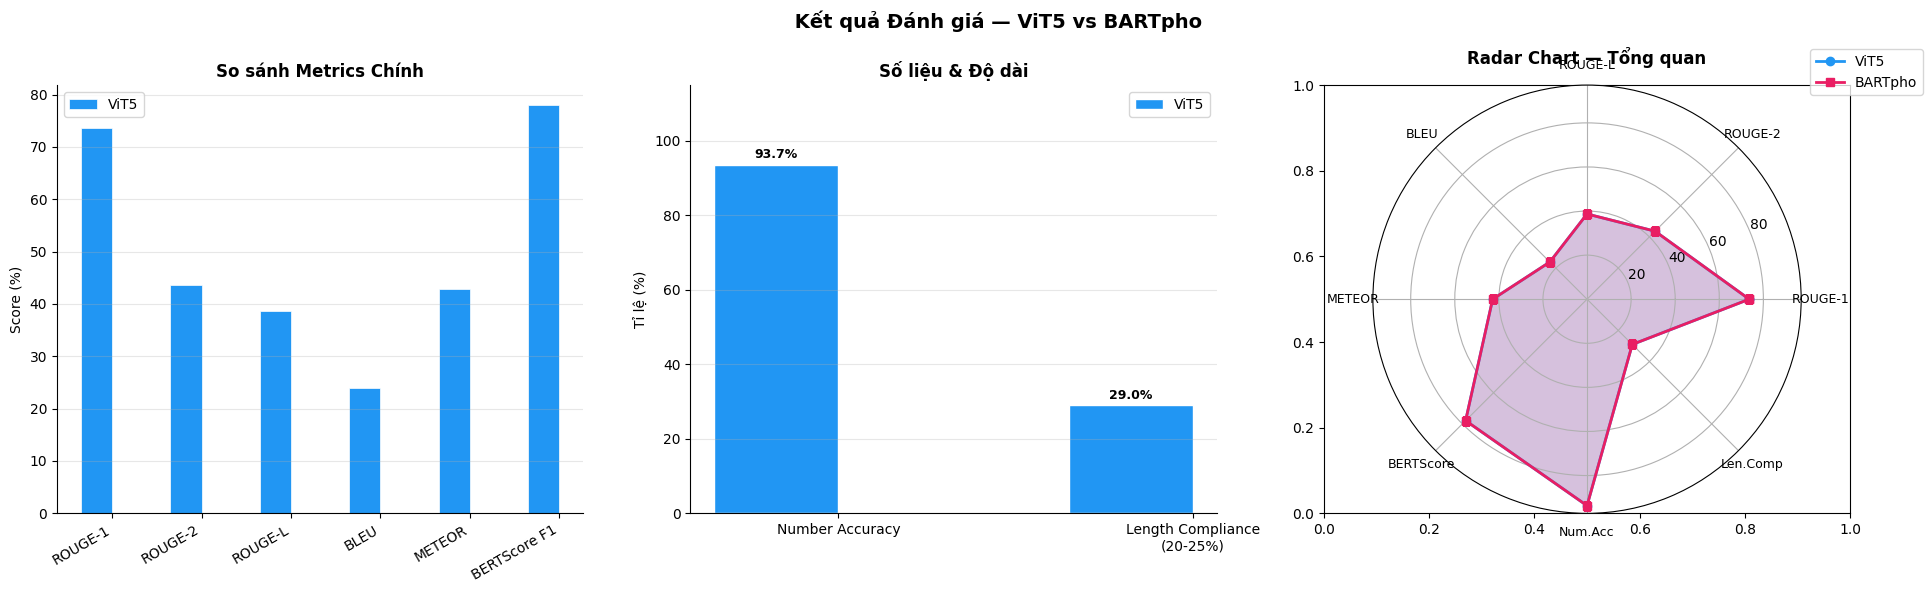

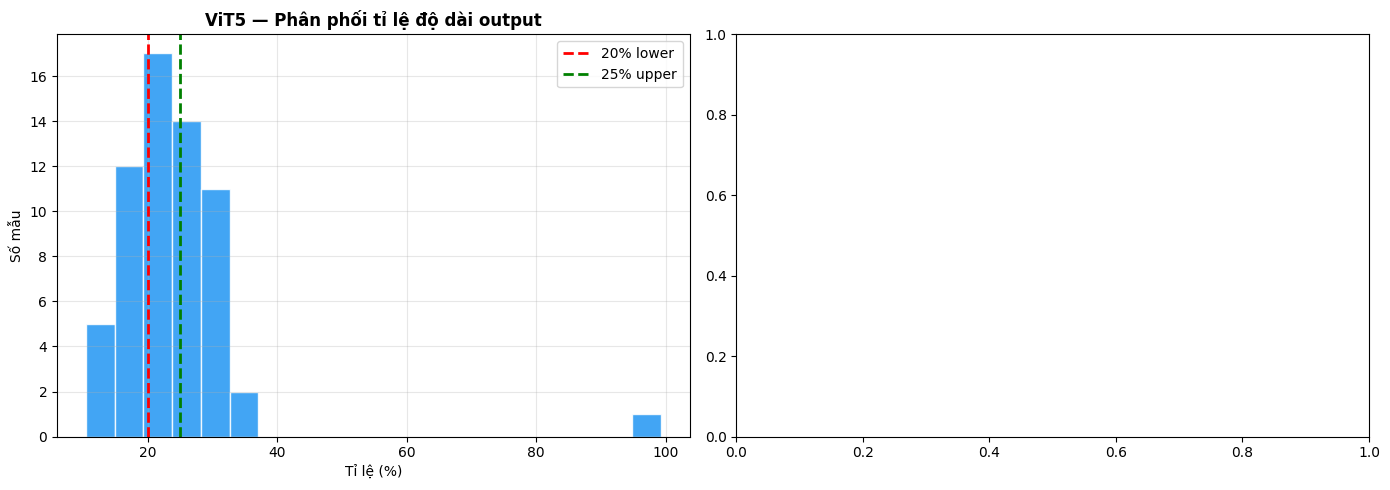

 Biểu đồ hoàn tất!


In [20]:
# ============================================================
# CELL 14 — BIỂU ĐỒ SO SÁNH METRICS
# ============================================================

def plot_metrics_comparison(vit5_metrics: dict, bart_metrics: dict, save_path: str = None):
    """Vẽ biểu đồ so sánh metrics giữa 2 models."""

    # ---- 1. Bar chart chính ----
    main_metrics = ['rouge1', 'rouge2', 'rougeL', 'bleu', 'meteor', 'bertscore_f1']
    labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU', 'METEOR', 'BERTScore F1']

    vit5_vals = [vit5_metrics[m] for m in main_metrics]
    bart_vals = [bart_metrics[m] for m in main_metrics]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Bar chart
    x = np.arange(len(labels))
    w = 0.35
    ax = axes[0]
    bars1 = ax.bar(x - w/2, vit5_vals, w, label='ViT5',    color='#2196F3', edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x + w/2, bart_vals, w, label='BARTpho', color='#E91E63', edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_ylabel('Score (%)')
    ax.set_title('So sánh Metrics Chính', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar in [*bars1, *bars2]:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}', ha='center', va='bottom', fontsize=7)

    # Number Accuracy & Length Compliance
    ax2 = axes[1]
    spec_metrics = ['number_accuracy', 'length_compliance']
    spec_labels  = ['Number Accuracy', 'Length Compliance\n(20-25%)']
    vit5_spec = [vit5_metrics[m] for m in spec_metrics]
    bart_spec = [bart_metrics[m] for m in spec_metrics]
    x2 = np.arange(len(spec_labels))
    ax2.bar(x2 - w/2, vit5_spec, w, label='ViT5',    color='#2196F3', edgecolor='white')
    ax2.bar(x2 + w/2, bart_spec, w, label='BARTpho', color='#E91E63', edgecolor='white')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(spec_labels)
    ax2.set_ylabel('Tỉ lệ (%)')
    ax2.set_ylim(0, 115)
    ax2.set_title('Số liệu & Độ dài', fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    for val, xp in zip(vit5_spec + bart_spec,
                       [x2[0]-w/2, x2[1]-w/2, x2[0]+w/2, x2[1]+w/2]):
        ax2.text(xp, val+1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Radar chart
    ax3 = axes[2]
    all_metrics_radar = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU', 'METEOR', 'BERTScore', 'Num.Acc', 'Len.Comp']
    vit5_r = [vit5_metrics[k] for k in ['rouge1','rouge2','rougeL','bleu','meteor','bertscore_f1','number_accuracy','length_compliance']]
    bart_r = [bart_metrics[k] for k in ['rouge1','rouge2','rougeL','bleu','meteor','bertscore_f1','number_accuracy','length_compliance']]

    n = len(all_metrics_radar)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    vit5_r_closed = vit5_r + [vit5_r[0]]
    bart_r_closed = bart_r + [bart_r[0]]
    angles_closed = angles + [angles[0]]

    ax3 = plt.subplot(1, 3, 3, polar=True)
    ax3.plot(angles_closed, vit5_r_closed, 'o-', color='#2196F3', lw=2, label='ViT5')
    ax3.fill(angles_closed, vit5_r_closed, alpha=0.2, color='#2196F3')
    ax3.plot(angles_closed, bart_r_closed, 's-', color='#E91E63', lw=2, label='BARTpho')
    ax3.fill(angles_closed, bart_r_closed, alpha=0.2, color='#E91E63')
    ax3.set_thetagrids(np.degrees(angles), all_metrics_radar, fontsize=9)
    ax3.set_title('Radar Chart — Tổng quan', fontweight='bold', pad=15)
    ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.suptitle(' Kết quả Đánh giá — ViT5 vs BARTpho', fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_metrics_comparison(
    vit5_metrics, bart_metrics,
    save_path=f'{OUTPUT_DIR}/metrics_comparison.png'
)

# ---- Phân tích distribution số liệu ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (preds, name, color) in zip(axes, [
    (vit5_preds, 'ViT5', '#2196F3'),
    (bart_preds, 'BARTpho', '#E91E63')
]):
    ratios = [count_words(p)/max(count_words(s),1)*100
              for p, s in zip(preds, test_sources)]
    ax.hist(ratios, bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(20, color='red', ls='--', lw=2, label='20% lower')
    ax.axvline(25, color='green', ls='--', lw=2, label='25% upper')
    ax.set_title(f'{name} — Phân phối tỉ lệ độ dài output', fontweight='bold')
    ax.set_xlabel('Tỉ lệ (%)')
    ax.set_ylabel('Số mẫu')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/output_length_distribution.png', dpi=150)
plt.show()
print(' Biểu đồ hoàn tất!')

In [25]:
# ============================================================
# CELL 17 — DEMO GRADIO
# ============================================================
import gradio as gr

# Load lại models từ disk nếu cần (hoặc dùng từ RAM)
# Uncomment nếu cần load lại từ đĩa:
# vit5_tokenizer = AutoTokenizer.from_pretrained(f'{OUTPUT_DIR}/vit5_final')
# vit5_model     = AutoModelForSeq2SeqLM.from_pretrained(f'{OUTPUT_DIR}/vit5_final').to(DEVICE)
# bart_tokenizer = AutoTokenizer.from_pretrained(f'{OUTPUT_DIR}/bartpho_final')
# bart_model     = AutoModelForSeq2SeqLM.from_pretrained(f'{OUTPUT_DIR}/bartpho_final').to(DEVICE)

DEMO_CSS = """
.metric-box {
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
    border: 1px solid #0f3460;
    border-radius: 10px;
    padding: 12px;
    color: #e0e0e0;
    font-family: 'Courier New', monospace;
}
.good-metric { color: #4CAF50; font-weight: bold; }
.bad-metric  { color: #F44336; font-weight: bold; }
.warn-metric { color: #FF9800; font-weight: bold; }
"""

def run_demo_summarization(text: str, model_choice: str, n_beams: int) -> tuple:
    """
    Hàm chính cho Gradio demo:
    - Sinh tóm tắt
    - Tính độ dài, tỉ lệ, số liệu
    """
    if not text or len(text.strip()) < 50:
        return ' Vui lòng nhập văn bản đủ dài (>50 ký tự).', '', '', '', ''

    # Chọn model
    if model_choice == 'ViT5':
        model, tokenizer, prefix = vit5_model, vit5_tokenizer, cfg_vit5['prefix']
    else:
        model, tokenizer, prefix = bart_model, bart_tokenizer, cfg_bart['prefix']

    # Sinh tóm tắt
    summary = generate_summary(
        model, tokenizer, text, prefix=prefix,
        n_beams=int(n_beams), post_process=True
    )

    # ---- Tính metrics ----
    src_words  = count_words(text)
    summ_words = count_words(summary)
    ratio_pct  = summ_words / max(src_words, 1) * 100
    na_score   = number_accuracy(text, summary) * 100
    lc_ok      = length_compliance(text, summary)

    src_nums  = extract_numbers(text)
    summ_nums = extract_numbers(summary)
    hallucinated = [n for n in summ_nums if n not in src_nums]

    # ---- Format kết quả ----
    ratio_status = '' if lc_ok else ('⚠️ Quá ngắn' if ratio_pct < 20 else '⚠️ Quá dài')
    na_status    = '' if na_score == 100 else ('⚠️' if na_score >= 80 else '❌')

    metrics_text = f"""📊 THỐNG KÊ TÓM TẮT
─────────────────────────────
 Gốc   : {src_words:,} từ
 Tóm tắt: {summ_words:,} từ
 Tỉ lệ  : {ratio_pct:.1f}% {ratio_status}
   (Mục tiêu: 20–25%)

 Number Accuracy: {na_score:.1f}% {na_status}
   (Số trong gốc: {len(src_nums)} | Trong TT: {len(summ_nums)})
"""

    if hallucinated:
        metrics_text += f"\n  Số liệu cần kiểm tra: {', '.join(list(hallucinated)[:8])}"
    else:
        metrics_text += "\n Tất cả số liệu đều có trong bản gốc!"

    # Highlight số trong summary
    highlighted_summary = NUMBER_PATTERN.sub(
        lambda m: f'**{m.group()}**', summary
    )

    return summary, highlighted_summary, metrics_text


# ---- Build Gradio Interface ----
with gr.Blocks(
    title=' Vietnamese Summarizer',
    theme=gr.themes.Base(
        primary_hue='blue',
        secondary_hue='pink',
        neutral_hue='slate',
        font=[gr.themes.GoogleFont('Inter'), 'ui-sans-serif']
    ),
    css=DEMO_CSS
) as demo:

    gr.Markdown('''
    #  Vietnamese News Summarizer
    ### Fine-tuned trên VnExpress | Ràng buộc 20–25% | Bảo toàn số liệu
    ---
    ''')

    with gr.Row():
        with gr.Column(scale=3):
            inp_text = gr.Textbox(
                label=' Văn bản gốc (dán bài báo tiếng Việt vào đây)',
                placeholder='Nhập hoặc dán văn bản tiếng Việt cần tóm tắt...',
                lines=12,
                max_lines=20,
            )
            with gr.Row():
                model_choice = gr.Radio(
                    choices=['ViT5', 'BARTpho'],
                    value='ViT5',
                    label=' Chọn mô hình'
                )
                n_beams = gr.Slider(
                    minimum=1, maximum=8, step=1, value=4,
                    label='🔍 Số beams (chất lượng vs tốc độ)'
                )
            btn = gr.Button(' Tóm tắt ngay!', variant='primary', size='lg')

        with gr.Column(scale=2):
            out_metrics = gr.Textbox(
                label=' Thống kê',
                lines=12,
                interactive=False,
                elem_classes=['metric-box']
            )

    with gr.Row():
        out_summary = gr.Textbox(
            label=' Bản tóm tắt',
            lines=6,
            interactive=False,
        )
        out_highlighted = gr.Markdown(
            label=' Số liệu được highlight (in đậm)',
        )

    with gr.Accordion(' Ví dụ mẫu', open=False):
        gr.Examples(
            examples=[
                [test_df['content'].iloc[0] if len(test_df) > 0 else 'Dán văn bản vào đây...', 'ViT5', 4],
                [test_df['content'].iloc[1] if len(test_df) > 1 else 'Dán văn bản vào đây...', 'BARTpho', 4],
            ],
            inputs=[inp_text, model_choice, n_beams],
            label='Chọn ví dụ từ tập test'
        )

    btn.click(
        fn=run_demo_summarization,
        inputs=[inp_text, model_choice, n_beams],
        outputs=[out_summary, out_highlighted, out_metrics],
    )

    gr.Markdown('''
    ---
    **Hướng dẫn đọc kết quả:**
    -  Tỉ lệ trong khoảng 20–25% → đạt yêu cầu
    -  Number Accuracy 100% → không hallucinate số liệu
    -  Có số liệu cần kiểm tra → xem lại thủ công
    - Số in **đậm** trong bản tóm tắt = số liệu được trích ra
    ''')

print(' Đang khởi động Gradio...')
demo.launch(
    share=True,
    debug=False,
    quiet=True,
    show_error=True,
)

 Đang khởi động Gradio...
* Running on public URL: https://ba369e18c5dc1ac683.gradio.live
